# Ground Radar Validation: NEXRAD

This notebook validates the ground-based radar analysis in TAT-C (`RadarStation`, `collect_radar_track`, and `compute_radar_track`, see the [Collect Radar Coverage](../examples/CollectRadarTrack.ipynb) example) against archived data from the same four NOAA NEXRAD (WSR-88D) weather radars used in the example: `KIWA` (Phoenix), `KFSX` (Flagstaff), `KYUX` (Yuma), and `KEMX` (Tucson).

TAT-C's *projected track* for a radar is the area within which a target at a given height lies between the radar's lowest and highest observed elevation angles (the lowest and highest scanned beam centers, extended by half the beam width) and within its maximum range, optionally reduced by an azimuthal terrain mask. The reference here is the area each radar actually sampled, reconstructed from its own archived volume scans. The comparison asks four questions:

1. **Station siting.** Do the station locations and heights in the example match the radars' own metadata?
2. **Scan strategy.** Do the default elevation angles and maximum range match the scans the radars actually performed?
3. **Terrain blockage.** Does a terrain mask derived from a digital elevation model (DEM) predict the azimuths where the radars' low beams are actually blocked?
4. **Observable area.** How does the projected track compare with the area actually sampled at 1,500, 3,048, and 6,096 m?

## Reference Data

[NEXRAD Level II](https://www.ncei.noaa.gov/products/radar/next-generation-weather-radar) data are the full-resolution base data of the WSR-88D network. Each file holds one volume scan (about 4 to 10 minutes): the station's location and antenna height, the volume coverage pattern (VCP) that defines the planned elevation cuts, and, for every sweep, radials of reflectivity and other moments at 250 m range gates. The archive is public on AWS Open Data ([`unidata-nexrad-level2`](https://registry.opendata.aws/noaa-nexrad/)) and requires no account. Files are decoded with MetPy's `Level2File` (`pip install metpy`).

Two precipitation events with echoes around all four radars are used:

* **20 March 2026**: widespread stratiform (winter) rain, with the radars in clear-air VCP 35.
* **29 September 2026**: late monsoon showers, with the radars in precipitation VCP 212.

Terrain blockage only needs the lowest few tilts, which come first in each file. Level II files are a sequence of independently compressed records of 120 radials each, so HTTP range requests download only the records needed. A sample of complete volumes provides the full scan strategy. The first run transfers about 3 GB and takes roughly 30 minutes; only reduced results are cached in a local `data/nexrad` directory, so later runs are fast.

The official station table, the [NCEI Historical Observing Metadata Repository NEXRAD list](https://www.ncei.noaa.gov/access/homr/file/nexrad-stations.txt), provides an independent source of station coordinates and elevations.

In [1]:
import concurrent.futures
import io
import json
import logging
import re
import struct
import warnings
from datetime import date, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from metpy.io import Level2File

logging.getLogger("metpy.io.nexrad").setLevel(logging.ERROR)

DATA_DIR = Path("data") / "nexrad"
DATA_DIR.mkdir(parents=True, exist_ok=True)
BUCKET = "https://unidata-nexrad-level2.s3.amazonaws.com/"
STATIONS = ["KIWA", "KFSX", "KYUX", "KEMX"]
EVENTS = [date(2026, 3, 20), date(2026, 9, 29)]
REFERENCE_TILT = 1.8  # deg; lower tilts are compared with this tilt to detect blockage


def list_volumes(day, station):
    """Keys of all Level II volume files for a station and UTC day."""
    keys, token = [], None
    while True:
        params = {"list-type": "2", "prefix": f"{day:%Y/%m/%d}/{station}/"}
        if token:
            params["continuation-token"] = token
        listing = requests.get(BUCKET, params=params, timeout=60).text
        keys += re.findall(r"<Key>(.*?)</Key>", listing)
        match = re.search(r"<NextContinuationToken>(.*?)</NextContinuationToken>", listing)
        if match is None:
            return [key for key in keys if key.endswith("_V06")]
        token = match.group(1)


def volume_time(key):
    return datetime.strptime(key[-19:-4], "%Y%m%d_%H%M%S")


def fetch_volume(key, n_records=None):
    """Download a Level II file, or only its first n_records compressed records."""
    if n_records is None:
        return requests.get(BUCKET + key, timeout=300).content
    data, chunk = b"", 2**21
    while True:
        response = requests.get(
            BUCKET + key, headers={"Range": f"bytes={len(data)}-{len(data) + chunk - 1}"}, timeout=120
        )
        if response.status_code == 206:
            data += response.content
        # a 24-byte volume header, then records each prefixed by a 4-byte (signed) size
        end, count = 24, 0
        while count < n_records and end + 4 <= len(data):
            size = abs(struct.unpack(">i", data[end : end + 4])[0])
            if end + 4 + size > len(data):
                break
            end, count = end + 4 + size, count + 1
        if count == n_records or response.status_code != 206 or len(response.content) < chunk:
            return data[:end]


def wrap(angle):
    """Elevation angle (deg) in [-180, 180)."""
    return angle - 360 if angle >= 180 else angle


def records_through(raw, angle):
    """Number of records from the start of a volume through the first cut at or above an elevation angle."""
    n_records = 1  # metadata record
    for cut in Level2File(io.BytesIO(raw)).vcp_info.els:
        n_records += (720 if "0.5 azimuth and 0.25km range res." in cut.super_res else 360) // 120
        if wrap(cut.el_angle) >= angle - 0.1:
            break
    return n_records + 1  # one record of margin


def describe_volume(raw):
    """Station metadata and one row per sweep of a complete volume."""
    radar = Level2File(io.BytesIO(raw))
    site = radar.sweeps[0][0][1]
    volume = {
        "vcp": radar.vcp_info.num,
        "planned_top": max(wrap(cut.el_angle) for cut in radar.vcp_info.els),
        "lat": site.lat,
        "lon": site.lon,
        "ground": site.site_amsl,
        "feedhorn": site.feedhorn_agl,
    }
    sweeps = []
    for sweep in radar.sweeps:
        header = sweep[0][4][b"REF"][0]
        sweeps.append(
            {
                "commanded": round(wrap(radar.vcp_info.els[sweep[0][0].el_num - 1].el_angle), 2),
                "measured": float(np.median([wrap(radial[0].el_angle) for radial in sweep])),
                "radials": len(sweep),
                "ref_range": header.first_gate + header.gate_width * header.num_gates,
            }
        )
    return volume, sweeps

### Complete Volumes

For the scan strategy (Tests 2 and 4), the volume nearest every third hour of each event is downloaded in full (16 volumes per station) and reduced to one row per sweep.

In [2]:
VOLUMES_FILE, SWEEPS_FILE = DATA_DIR / "volumes.csv", DATA_DIR / "sweeps.csv"

if not (VOLUMES_FILE.exists() and SWEEPS_FILE.exists()):
    jobs = []
    for station in STATIONS:
        for day in EVENTS:
            keys = list_volumes(day, station)
            times = np.array([volume_time(key) for key in keys])
            for hour in range(0, 24, 3):
                target = datetime(day.year, day.month, day.day, hour)
                jobs.append((station, keys[np.argmin(np.abs(times - target))]))

    def reduce_volume(job):
        station, key = job
        volume, sweeps = describe_volume(fetch_volume(key))
        info = {"station": station, "key": key, "time": volume_time(key)}
        return {**info, **volume}, [{**info, **sweep} for sweep in sweeps]

    with concurrent.futures.ThreadPoolExecutor(8) as pool:
        reduced = list(pool.map(reduce_volume, jobs))
    pd.DataFrame([volume for volume, _ in reduced]).to_csv(VOLUMES_FILE, index=False)
    pd.DataFrame([sweep for _, sweeps in reduced for sweep in sweeps]).to_csv(SWEEPS_FILE, index=False)

volumes = pd.read_csv(VOLUMES_FILE, parse_dates=["time"])
sweeps = pd.read_csv(SWEEPS_FILE, parse_dates=["time"])
volumes.groupby(["station", "vcp"]).size().unstack(fill_value=0)

vcp,35,212,215
station,,,
KEMX,8,8,0
KFSX,8,8,0
KIWA,7,8,1
KYUX,8,8,0


### Low-Tilt Reflectivity

For terrain blockage (Test 3), every sixth volume of each event (about every 30 minutes in VCP 212 and every hour in VCP 35) is downloaded through the 1.8 deg cut. Linear reflectivity factor is accumulated in 1 deg azimuth by 1 km range bins out to 100 km for each surveillance tilt and, for the same volumes, for the 1.8 deg reference tilt. Gates below the detection threshold count as zero.

In [3]:
RANGE_BINS = 100  # km


def accumulate(key):
    """Accumulated linear reflectivity (360 x RANGE_BINS) by commanded tilt for one volume."""
    raw = fetch_volume(key, 1)
    raw = fetch_volume(key, records_through(raw, REFERENCE_TILT))
    radar = Level2File(io.BytesIO(raw))
    tilts = {}
    for sweep in radar.sweeps:
        moments = sweep[0][4]
        if b"CFP" not in moments or len(sweep) < 360:
            continue  # Doppler-only cut of a split cut, or an incomplete sweep
        header = moments[b"REF"][0]
        n_gates = int((RANGE_BINS - header.first_gate) / header.gate_width)
        range_bin = (header.first_gate + header.gate_width * np.arange(n_gates)).astype(int)
        z, n = np.zeros((360, RANGE_BINS)), np.zeros((360, RANGE_BINS))
        for radial in sweep:
            dbz = radial[4][b"REF"][1][:n_gates]
            azimuth = int(radial[0].az_angle) % 360
            np.add.at(z[azimuth], range_bin[: len(dbz)], np.where(np.isfinite(dbz), 10 ** (dbz / 10), 0))
            np.add.at(n[azimuth], range_bin[: len(dbz)], 1)
        commanded = round(wrap(radar.vcp_info.els[sweep[0][0].el_num - 1].el_angle), 1)
        measured = np.median([wrap(radial[0].el_angle) for radial in sweep])
        tilts[commanded] = (measured, z, n)
    return radar.vcp_info.num, tilts


def blockage_statistics(station):
    path = DATA_DIR / f"blockage_{station}.npz"
    if not path.exists():
        keys = [key for day in EVENTS for key in list_volumes(day, station)[::6]]
        with concurrent.futures.ThreadPoolExecutor(8) as pool:
            results = list(pool.map(accumulate, keys))
        tilts = sorted({tilt for _, volume in results for tilt in volume if tilt <= REFERENCE_TILT})
        shape = (len(tilts), 360, RANGE_BINS)
        z, n, z_ref, n_ref = np.zeros(shape), np.zeros(shape), np.zeros(shape), np.zeros(shape)
        measured = [[] for _ in tilts]
        for _, volume in results:
            if REFERENCE_TILT not in volume:
                continue
            for i, tilt in enumerate(tilts):
                if tilt in volume:
                    measured[i].append(volume[tilt][0])
                    z[i] += volume[tilt][1]
                    n[i] += volume[tilt][2]
                    z_ref[i] += volume[REFERENCE_TILT][1]
                    n_ref[i] += volume[REFERENCE_TILT][2]
        np.savez(
            path,
            keys=keys,
            vcp=[vcp for vcp, _ in results],
            commanded=tilts,
            measured=[np.median(m) for m in measured],
            volumes=[len(m) for m in measured],
            z=z,
            n=n,
            z_ref=z_ref,
            n_ref=n_ref,
        )
    return dict(np.load(path))


blockage = {station: blockage_statistics(station) for station in STATIONS}
pd.DataFrame(
    {
        station: {
            "volumes": len(stats["keys"]),
            "tilts (deg)": ", ".join(f"{m:.2f}" for m in stats["measured"]),
        }
        for station, stats in blockage.items()
    }
).T

,volumes,tilts (deg)
KIWA,83,"0.53, 0.92, 1.32, 1.85"
KFSX,78,"-0.13, 0.53, 0.92, 1.32, 1.85"
KYUX,81,"0.53, 0.92, 1.32, 1.85"
KEMX,85,"0.44, 0.83, 1.23, 1.76"


## Setup

The example's station definitions (coordinates, elevations, and NEXRAD defaults) are reproduced exactly; Test 4 pairs them with the DEM terrain masks computed in Test 3. Beam heights use TAT-C's own standard-atmosphere (4/3 effective Earth radius) beam model, so differences in Tests 2 and 4 isolate the scan strategy, beam width, and blockage rather than refraction. The WSR-88D half-power beamwidth is about 0.95 deg.

All heights in this notebook are above mean sea level (MSL), the reference used by both the Level II metadata and the DEM. TAT-C's coverage depends only on the height of the target relative to the antenna, so a common vertical offset (such as the geoid undulation in Test 1) does not change the comparison.

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import shapely
from matplotlib.colors import ListedColormap
from pyproj import Geod

from tatc import constants
from tatc.analysis import collect_radar_track, compute_radar_track
from tatc.schemas import RadarBand, RadarStation, TerrainMask
from tatc.utils.radar import compute_radar_beam_height

EXAMPLE = {
    "KIWA": (33.289233, -111.66991, 434.6),
    "KFSX": (34.574333, -111.19844, 2290.3),
    "KYUX": (32.495281, -114.65671, 72.8),
    "KEMX": (31.89365, -110.63025, 1621.2),
}
EXAMPLE_MIN_ELEVATION_ANGLE = {"KFSX": -0.2}
example_stations = {
    name: RadarStation.from_band(
        RadarBand.S,
        name=name,
        latitude=lat,
        longitude=lon,
        elevation=elevation,
        min_elevation_angle=EXAMPLE_MIN_ELEVATION_ANGLE.get(name, 0.5),
    )
    for name, (lat, lon, elevation) in EXAMPLE.items()
}

GEOD = Geod(ellps="WGS84")
BEAMWIDTH = 0.95  # deg
EFFECTIVE_RADIUS = constants.EFFECTIVE_EARTH_RADIUS_FACTOR * constants.EARTH_MEAN_RADIUS
HEIGHTS = [1500, 3048, 6096]  # m MSL


def ground_range(slant_range, elevation_angle, antenna):
    """Ground range (m) along a beam; a vectorized form of tatc.utils.radar.compute_radar_ground_range."""
    height = compute_radar_beam_height(slant_range, elevation_angle, antenna)
    theta = np.radians(elevation_angle)
    return EFFECTIVE_RADIUS * np.arcsin(
        np.minimum(slant_range * np.cos(theta) / (EFFECTIVE_RADIUS + height - antenna), 1)
    )


def interpolate_mask(mask):
    """Minimum elevation angle (deg) of a terrain mask at 1-deg azimuth bin centers."""
    return np.array([mask.get_min_elevation_angle(azimuth) for azimuth in np.arange(360) + 0.5])


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## Test 1: Station Siting

Each Level II volume reports the station's latitude, longitude, ground elevation (m MSL), and the height of the antenna feedhorn above ground. `RadarStation.elevation` is the antenna height, so the reference is ground elevation plus feedhorn height. The NCEI station table lists the same antenna elevation in feet.

In [5]:
import pyproj

NCEI_FILE = DATA_DIR / "nexrad-stations.txt"
if not NCEI_FILE.exists():
    NCEI_FILE.write_bytes(
        requests.get("https://www.ncei.noaa.gov/access/homr/file/nexrad-stations.txt", timeout=60).content
    )
lines = [line for line in NCEI_FILE.read_text(encoding="utf-8").splitlines() if line.strip()]
spans = [(m.start(), m.end()) for m in re.finditer(r"-+", lines[1])]
ncei = pd.read_fwf(io.StringIO("\n".join(lines)), colspecs=spans, skiprows=[1]).set_index("ICAO")

pyproj.network.set_network_enabled(True)  # downloads the EGM96 geoid grid if not installed
to_ellipsoid = pyproj.Transformer.from_crs("EPSG:4326+5773", "EPSG:4979", always_xy=True)

site = volumes.groupby("station")[["lat", "lon", "ground", "feedhorn"]].first()
site["antenna"] = site.ground + site.feedhorn
test1 = {}
for name in STATIONS:
    lat, lon, elevation = EXAMPLE[name]
    undulation = to_ellipsoid.transform(site.lon[name], site.lat[name], 0)[2]
    test1[name] = {
        "example horizontal offset (m)": GEOD.inv(lon, lat, site.lon[name], site.lat[name])[2],
        "NCEI horizontal offset (m)": GEOD.inv(
            ncei.LON[name], ncei.LAT[name], site.lon[name], site.lat[name]
        )[2],
        "Level II ground (m MSL)": site.ground[name],
        "Level II feedhorn (m AGL)": site.feedhorn[name],
        "Level II antenna (m MSL)": site.antenna[name],
        "NCEI elevation (m MSL)": ncei.ELEV[name] * 0.3048,
        "example elevation (m)": elevation,
        "example minus antenna (m)": elevation - site.antenna[name],
        "geoid undulation (m)": undulation if abs(undulation) > 1e-6 else np.nan,
    }
test1 = pd.DataFrame(test1)
test1.round(1)

,KIWA,KFSX,KYUX,KEMX
example horizontal offset (m),0.4,0.8,0.2,0.1
NCEI horizontal offset (m),0.4,0.8,0.2,0.1
Level II ground (m MSL),415.0,2261.0,53.0,1586.0
Level II feedhorn (m AGL),19.0,29.0,19.0,34.0
Level II antenna (m MSL),434.0,2290.0,72.0,1620.0
NCEI elevation (m MSL),434.6,2290.3,72.8,1621.2
example elevation (m),434.6,2290.3,72.8,1621.2
example minus antenna (m),0.6,0.3,0.8,1.2
geoid undulation (m),-30.1,-24.5,-34.5,-28.9


The example's coordinates and elevations are taken from the NCEI table. They agree with the radars' own Level II metadata to within a few meters horizontally and about 1 m vertically, confirming that the NCEI elevation is the antenna height (ground elevation plus feedhorn height) that `RadarStation.elevation` represents. (An earlier version of the example used approximate elevations, including 174 m for `KYUX`, whose antenna is at 72 m; a height error matters most for the terrain mask, because the terrain angle seen from the antenna changes by about 0.6 deg per 100 m at 10 km.)

`RadarStation.elevation` and target elevations must use the same vertical reference. The Level II, NCEI, and Copernicus DEM heights are all above mean sea level, which differs from the WGS 84 ellipsoid by the geoid undulation (about -30 m in this region), so this notebook, like the example, uses heights above mean sea level throughout.

## Test 2: Scan Strategy

TAT-C's NEXRAD defaults are a lowest elevation angle of 0.5 deg, a highest of 19.5 deg, a maximum range of 460 km, and a beam width of 0.95 deg. The table summarizes the scans the radars actually performed. The highest tilt reached varies because WSR-88D volume scans end early (Automated Volume Scan Evaluation and Termination, AVSET) when no significant echoes remain at higher tilts, and clear-air VCP 35 tops out at 6.4 deg.

In [6]:
cuts = sweeps.groupby(["station", "key", "commanded"]).agg(measured=("measured", "median"), ref_range=("ref_range", "max")).reset_index()
per_volume = cuts.groupby(["station", "key"]).agg(
    lowest=("measured", "min"), highest=("measured", "max"), n_cuts=("measured", "size"), ref_range=("ref_range", "max")
).join(volumes.set_index(["station", "key"])[["vcp", "planned_top"]])
test2 = {}
for name in STATIONS:
    v = per_volume.loc[name]
    vcps = pd.Series(blockage[name]["vcp"]).value_counts(normalize=True)
    test2[name] = {
        "VCPs used (share)": ", ".join(f"{vcp} ({share:.0%})" for vcp, share in vcps.items()),
        "lowest tilt (deg)": v.lowest.median(),
        "highest tilt, VCP 212: min (deg)": v.highest[v.vcp == 212].min(),
        "highest tilt, VCP 212: median (deg)": v.highest[v.vcp == 212].median(),
        "highest tilt, VCP 212: max (deg)": v.highest[v.vcp == 212].max(),
        "highest tilt, VCP 35: median (deg)": v.highest[v.vcp == 35].median(),
        "VCP 212 volumes ended early": np.mean(v.highest[v.vcp == 212] < v.planned_top[v.vcp == 212] - 0.2),
        "reflectivity range, low tilts (km)": v.ref_range.median(),
    }
pd.DataFrame(test2).round(2)

,KIWA,KFSX,KYUX,KEMX
VCPs used (share),"212 (58%), 35 (39%), 215 (4%)","212 (64%), 35 (36%)","212 (64%), 35 (36%)","212 (60%), 35 (40%)"
lowest tilt (deg),0.527344,-0.131836,0.527344,0.439453
"highest tilt, VCP 212: min (deg)",10.019531,6.416016,6.416016,7.954102
"highest tilt, VCP 212: median (deg)",19.467773,14.018555,6.459961,15.996094
"highest tilt, VCP 212: max (deg)",19.467773,19.511719,12.436523,19.511719
"highest tilt, VCP 35: median (deg)",6.459961,6.416016,6.459961,6.37207
VCP 212 volumes ended early,0.375,0.75,1.0,0.5
"reflectivity range, low tilts (km)",460.125,460.125,460.125,460.125


The diagram below compares the half-power beams of a complete VCP 212 volume (blue) with the region TAT-C treats as observable with the example's defaults (orange: from the lower half-power edge of the lowest beam to the upper edge of the highest, out to 460 km slant range). Dotted lines mark the target heights used in Test 4.

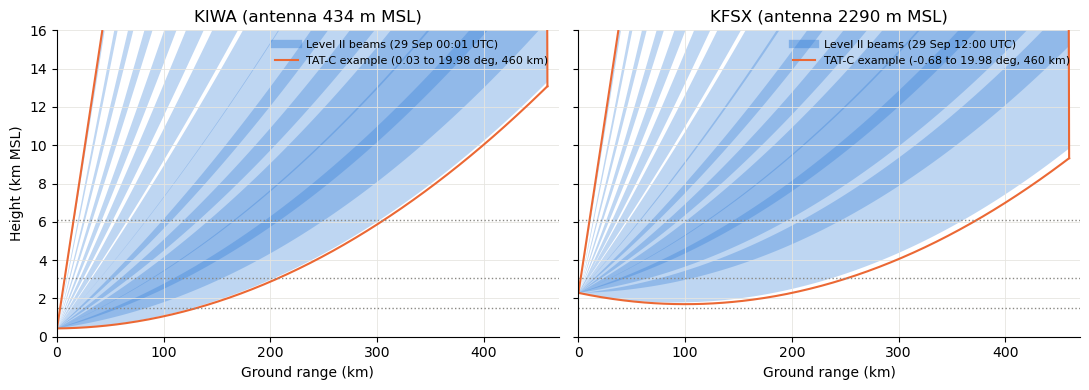

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ["KIWA", "KFSX"]):
    full = per_volume.loc[name]
    key = full[(full.vcp == 212)].highest.idxmax()
    antenna = site.antenna[name]
    for _, cut in cuts[(cuts.station == name) & (cuts.key == key)].iterrows():
        s = np.linspace(0, cut.ref_range * 1e3, 300)
        ax.fill_between(
            ground_range(s, cut.measured, antenna) / 1e3,
            compute_radar_beam_height(s, cut.measured - BEAMWIDTH / 2, antenna) / 1e3,
            compute_radar_beam_height(s, cut.measured + BEAMWIDTH / 2, antenna) / 1e3,
            color=BLUE,
            alpha=0.3,
            lw=0,
        )
    example = example_stations[name]
    s = np.linspace(0, example.max_range, 300)
    lowest, highest = example.min_elevation_angle - example.beam_width / 2, example.get_effective_max_elevation_angle()
    arc = np.linspace(lowest, highest, 100)
    for x, y in [
        *[(ground_range(s, el, example.elevation), compute_radar_beam_height(s, el, example.elevation)) for el in (lowest, highest)],
        (ground_range(example.max_range, arc, example.elevation), compute_radar_beam_height(example.max_range, arc, example.elevation)),
    ]:
        ax.plot(x / 1e3, y / 1e3, color=ORANGE, lw=1.5)
    for height in HEIGHTS:
        ax.axhline(height / 1e3, color=GRAY, ls=":", lw=1)
    ax.plot([], [], color=BLUE, alpha=0.4, lw=6, label=f"Level II beams ({volume_time(key):%d %b %H:%M} UTC)")
    ax.plot([], [], color=ORANGE, label=f"TAT-C example ({lowest:.2f} to {highest:.2f} deg, {example.max_range / 1e3:.0f} km)")
    ax.set(xlim=(0, 470), ylim=(0, 16), xlabel="Ground range (km)", title=f"{name} (antenna {antenna:.0f} m MSL)")
    ax.legend(frameon=False, loc="upper right", fontsize=8)
axes[0].set_ylabel("Height (km MSL)")
fig.tight_layout()
plt.show()

Three differences stand out:

* **Lowest tilt.** `KFSX`, on a mountaintop, scans below the horizon (commanded -0.18 deg, measured -0.13 deg), which the example represents with `min_elevation_angle=-0.2`. This matters: at the 0.5 deg default, `KFSX`'s beam center would climb past 3,048 m about 60 km away instead of about 140 km.
* **Range.** Level II reflectivity on the low (surveillance) tilts extends to 460 km, which `RadarStation` uses as its default. (The 230 km range often quoted for NEXRAD belongs to the base reflectivity display product, not the measurement.) Higher tilts end where the beam reaches about 21 km (70,000 ft).
* **Highest tilt.** Even in VCP 212 the highest tilt reached varies from volume to volume because of AVSET, and VCP 35 never exceeds 6.4 deg, so the overhead "cone of silence" is often much larger than the 19.5 deg default implies.

The half-power beam extends about 0.5 deg beyond the lowest and highest beam centers, which TAT-C represents with `RadarStation.beam_width` (0.95 deg by default). TAT-C treats the angles in between as continuously sampled, so it does not represent the gaps that open between the beams of the widely spaced upper tilts.

## Test 3: Terrain Blockage

A beam blocked by terrain returns weaker echoes from precipitation behind the obstacle than an unobstructed beam does. For each azimuth, the median ratio (dB) between each low tilt's mean reflectivity and the 1.8 deg reference tilt's, over 20 to 80 km where the reference tilt sees precipitation (a mean of at least 5 dBZ over both events), is normalized by its 75th percentile across azimuths (an unblocked baseline, which absorbs the average vertical change in reflectivity). A tilt is considered *observed blocked* at an azimuth when this deficit is below -3 dB, i.e. more than half the echo power is lost. Azimuths without precipitation, or where even the reference tilt is blocked, remain unverified.

TAT-C's terrain masks are computed with `tatc.preprocess.compute_terrain_mask` from the Copernicus GLO-30 DEM using the Level II antenna heights at 1 deg azimuth resolution out to 100 km, with the default 400 geometrically spaced range samples (dense near the station, where small sampling errors produce the largest angle errors). A tilt is expected to be blocked where the mask angle exceeds the tilt (beam center). The example notebook's precomputed masks use the same settings with the NCEI antenna heights (within 1.2 m of Level II), so they are essentially identical and are not evaluated separately.

In [8]:
from tatc.preprocess import compute_terrain_mask, get_copernicus_dem_tile_urls

dem_masks = {}
for name in STATIONS:
    path = DATA_DIR / f"terrain_mask_{name}.json"
    if not path.exists():
        mask = compute_terrain_mask(
            get_copernicus_dem_tile_urls(site.lon[name], site.lat[name], radius=100000),
            site.lon[name],
            site.lat[name],
            site.antenna[name],
            search_radius=100000,
        )
        path.write_text(json.dumps(mask.model_dump()), encoding="utf-8")
    dem_masks[name] = TerrainMask(**json.loads(path.read_text(encoding="utf-8")))
mask_angle = {name: interpolate_mask(mask) for name, mask in dem_masks.items()}


def blockage_deficit(stats, min_range=20, max_range=80, min_dbz=5):
    """Normalized reflectivity deficit (dB) of each tilt below the reference tilt, by 1-deg azimuth."""
    with np.errstate(divide="ignore", invalid="ignore"):
        z = stats["z"] / stats["n"]
        z_ref = stats["z_ref"] / stats["n_ref"]
        ratio = np.clip(10 * np.log10(z / z_ref), -30, None)
        ratio[~(10 * np.log10(z_ref) >= min_dbz)] = np.nan
    ratio[:, :, :min_range] = np.nan
    ratio[:, :, max_range:] = np.nan
    lower = stats["commanded"] < REFERENCE_TILT - 0.05
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)  # all-NaN azimuths
        deficit = np.nanmedian(ratio[lower], axis=2)
    deficit[np.sum(np.isfinite(ratio[lower]), axis=2) < 10] = np.nan
    return deficit - np.nanpercentile(deficit, 75, axis=1, keepdims=True), stats["measured"][lower]


deficits = {name: blockage_deficit(blockage[name]) for name in STATIONS}

rows = []
for name in STATIONS:
    deficit, tilts = deficits[name]
    for k, tilt in enumerate(tilts):
        valid = np.isfinite(deficit[k])
        observed = deficit[k] < -3
        predicted = mask_angle[name] > tilt
        rows.append(
            {
                "station": name,
                "tilt (deg)": tilt,
                "verified azimuths": valid.sum(),
                "observed blocked": (observed & valid).sum(),
                "predicted blocked": (predicted & valid).sum(),
                "agreement": np.mean((observed == predicted)[valid]),
            }
        )
test3 = pd.DataFrame(rows).set_index(["station", "tilt (deg)"])
test3.round(3)

verified azimuths  observed blocked  predicted blocked  \
station tilt (deg)                                                           
KIWA     0.527344                 360               184                159   
         0.922852                 360               157                 93   
         1.318359                 360                67                 35   
KFSX    -0.131836                 360               180                148   
         0.527344                 360                34                  0   
         0.922852                 360                15                  0   
         1.318359                 360                 1                  0   
KYUX     0.527344                 353                51                 33   
         0.922852                 353                 2                  5   
         1.318359                 353                 0                  0   
KEMX     0.439453                 338               158                136   
         0.834961                 338               100                 88   
         1.230469                 338                68                 45   

                    agreement  
station tilt (deg)             
KIWA     0.527344       0.908  
         0.922852       0.822  
         1.318359       0.900  
KFSX    -0.131836       0.906  
         0.527344       0.906  
         0.922852       0.958  
         1.318359       0.997  
KYUX     0.527344       0.915  
         0.922852       0.992  
         1.318359       1.000  
KEMX     0.439453       0.905  
         0.834961       0.964  
         1.230469       0.932

The figure shows the observed deficit for each tilt and azimuth (red: weaker than unblocked) with the DEM-derived mask angle (black line). Gray marks unverified azimuths. TAT-C predicts a tilt blocked wherever the mask line lies above it.

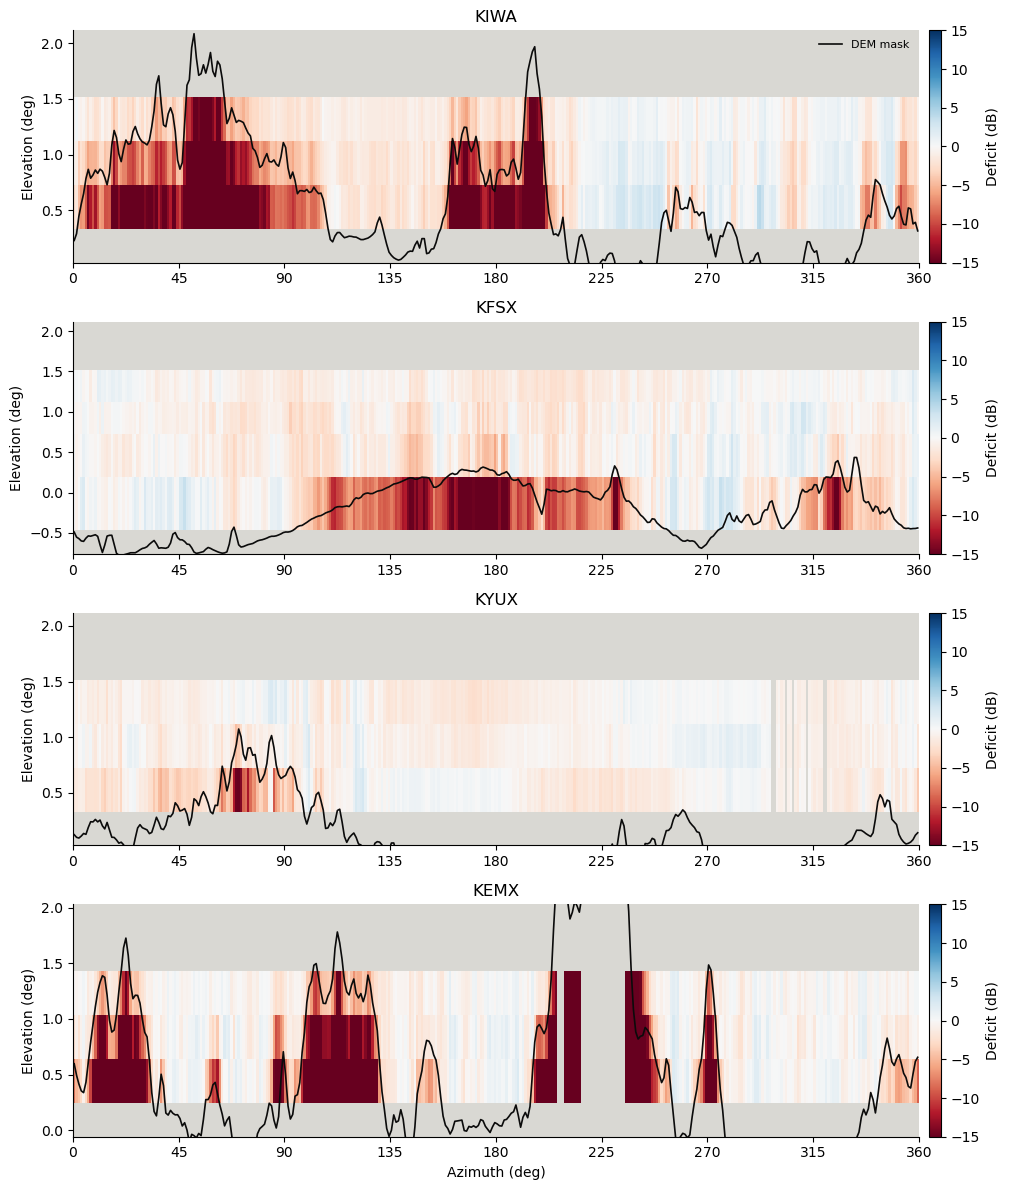

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12))
for ax, name in zip(axes, STATIONS):
    deficit, tilts = deficits[name]
    edges = np.r_[tilts[0] - (tilts[1] - tilts[0]) / 2, (tilts[1:] + tilts[:-1]) / 2, tilts[-1] + (tilts[-1] - tilts[-2]) / 2]
    ax.set_facecolor("#d9d8d3")
    mesh = ax.pcolormesh(np.arange(361), edges, deficit, cmap="RdBu", vmin=-15, vmax=15)
    ax.plot(np.arange(360) + 0.5, mask_angle[name], color=INK, lw=1.2, label="DEM mask")
    ax.set(xlim=(0, 360), ylim=(edges[0] - 0.3, edges[-1] + 0.6), ylabel="Elevation (deg)", title=name)
    ax.set_xticks(range(0, 361, 45))
    ax.grid(False)
    fig.colorbar(mesh, ax=ax, label="Deficit (dB)", pad=0.01)
axes[0].legend(frameon=False, loc="upper right", fontsize=8)
axes[-1].set_xlabel("Azimuth (deg)")
fig.tight_layout()
plt.show()

The DEM masks trace the observed blockage closely: the sectors northeast, east, and south of `KIWA`, south and northwest of `KFSX`, east of `KYUX` (the Gila Mountains), and north, east, and southwest of `KEMX` (the Santa Rita Mountains, where even the 1.8 deg reference tilt is blocked and the azimuths remain unverified) all appear where predicted. DEM sampling matters: with the coarser settings of an earlier version of the example (5 deg azimuths, a 50 km search radius, and 1 km range spacing), agreement was up to 13 percentage points lower (69% instead of 82% for `KIWA`'s 0.9 deg tilt), mostly because terrain 50 to 100 km away sets the blocking angle along many azimuths around these stations. Evenly spaced range samples (every 0.5 km) also skipped a narrow ridge close to `KEMX`, underestimating its blocking angle by up to 2.2 deg and lowering agreement at its lowest tilt from 90% to 84%. Most disagreements are azimuths observed blocked where the mask lies just below the tilt.

Pooling all stations and tilts, the observed deficit is plotted against the mask angle relative to the tilt, and the agreement is recomputed with the blocking criterion offset, `mask > tilt - offset`.

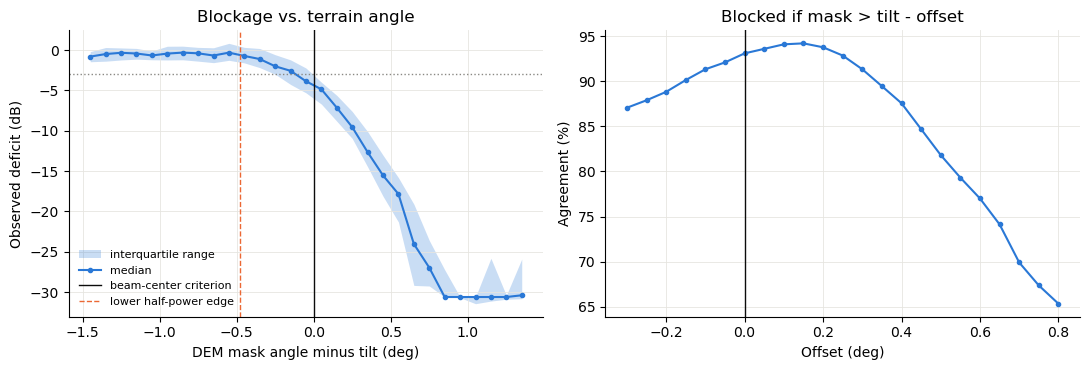

verified tilt-azimuth pairs      4593.000
agreement at offset 0 (TAT-C)       0.931
best offset (deg)                   0.150
agreement at best offset            0.942
dtype: float64

In [10]:
x = np.concatenate([(mask_angle[n][np.newaxis, :] - deficits[n][1][:, np.newaxis]).ravel() for n in STATIONS])
y = np.concatenate([deficits[n][0].ravel() for n in STATIONS])
valid = np.isfinite(y)
x, y = x[valid], y[valid]

offsets = np.arange(-0.3, 0.81, 0.05)
agreement = [np.mean((y < -3) == (x > -offset)) for offset in offsets]
best_offset = offsets[int(np.argmax(agreement))]

edges = np.arange(-1.5, 1.51, 0.1)
centers = (edges[1:] + edges[:-1]) / 2
quantiles = np.array([np.percentile(y[(x >= lo) & (x < hi)], [25, 50, 75]) if np.sum((x >= lo) & (x < hi)) > 5 else [np.nan] * 3 for lo, hi in zip(edges[:-1], edges[1:])])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].fill_between(centers, quantiles[:, 0], quantiles[:, 2], color=BLUE, alpha=0.25, lw=0, label="interquartile range")
axes[0].plot(centers, quantiles[:, 1], color=BLUE, marker="o", ms=3, label="median")
axes[0].axhline(-3, color=GRAY, ls=":", lw=1)
axes[0].axvline(0, color=INK, lw=1, label="beam-center criterion")
axes[0].axvline(-BEAMWIDTH / 2, color=ORANGE, lw=1, ls="--", label="lower half-power edge")
axes[0].set(xlabel="DEM mask angle minus tilt (deg)", ylabel="Observed deficit (dB)", title="Blockage vs. terrain angle")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
axes[1].plot(offsets, np.array(agreement) * 100, color=BLUE, marker="o", ms=3)
axes[1].axvline(0, color=INK, lw=1)
axes[1].set(xlabel="Offset (deg)", ylabel="Agreement (%)", title="Blocked if mask > tilt - offset")
fig.tight_layout()
plt.show()
pd.Series(
    {
        "verified tilt-azimuth pairs": valid.sum(),
        "agreement at offset 0 (TAT-C)": agreement[int(np.argmin(np.abs(offsets)))],
        "best offset (deg)": best_offset,
        "agreement at best offset": max(agreement),
    }
).round(3)

Echo power begins to drop once the terrain angle comes within about 0.3 deg of the tilt (the lower part of the 0.95 deg beam meets the terrain first) and falls below -3 dB about 0.1 deg before the terrain reaches the beam center. A beam-center criterion is therefore a good approximation of when a tilt is lost: shifting it by the best offset of 0.15 deg improves agreement by only about 1 percentage point. TAT-C's coverage model is consistent with this gradual loss, since its lowest observed angle is the greater of the lowest beam's lower half-power edge and the terrain angle, so coverage shrinks progressively as terrain rises through the lower half of the beam. Beyond the criterion, the remaining disagreements reflect the single-ridge mask model, DEM error, and precipitation sampling.

## Test 4: Observable Area

The **observed coverage** of a volume at a target height is the set of locations (1 deg by 1 km polar cells) where at least one of the volume's actual sweeps has its half-power beam (center +/- 0.475 deg) spanning that height within the sweep's reflectivity range, excluding sweeps blocked at that azimuth. Blockage is taken from Test 3 where verified, and otherwise from the DEM mask with the best offset (for unverified azimuths and tilts at or above 1.8 deg). Like TAT-C's terrain mask, a blocked azimuth is excluded at all ranges.

This is compared with TAT-C's projected track (`collect_radar_track`) in three configurations:

* **Example**: the example notebook's stations (coordinates, elevations, and NEXRAD defaults including the 0.95 deg beam width), with the DEM masks from Test 3.
* **Matched**: Level II coordinates and antenna heights, the volume's actual lowest and highest tilts, 460 km range, the 0.95 deg beam width, and the DEM masks from Test 3.
* **Matched, beam centers**: as above with `beam_width=0`, so coverage is bounded by the lowest and highest beam centers.

Metrics are areas and the intersection over union (IoU) between observed and projected areas, with medians over the 16 complete volumes per station.

In [11]:
GRID_AZIMUTH = np.arange(360) + 0.5
GRID_RANGE = np.arange(460) + 0.5  # km
CELL_AREA = np.radians(1) * GRID_RANGE  # km^2


def blocked_azimuths(name, angle):
    """Azimuth bins where a beam at this elevation angle is blocked."""
    dem = mask_angle[name] > angle - best_offset
    deficit, tilts = deficits[name]
    k = np.argmin(np.abs(tilts - angle))
    if abs(tilts[k] - angle) > 0.15:
        return dem
    return np.where(np.isfinite(deficit[k]), deficit[k] < -3, dem)


def observed_coverage(name, key, height):
    antenna = site.antenna[name]
    coverage = np.zeros((360, 460), dtype=bool)
    for _, cut in cuts[(cuts.station == name) & (cuts.key == key)].iterrows():
        s = np.arange(0, cut.ref_range * 1e3, 250.0)
        lower = compute_radar_beam_height(s, cut.measured - BEAMWIDTH / 2, antenna)
        upper = compute_radar_beam_height(s, cut.measured + BEAMWIDTH / 2, antenna)
        spans = (lower <= height) & (upper >= height)
        if spans.any():
            ring = np.zeros(460, dtype=bool)
            ring[np.clip((ground_range(s[spans], cut.measured, antenna) / 1e3).astype(int), 0, 459)] = True
            coverage[~blocked_azimuths(name, cut.measured)] |= ring
    return coverage


example_stations = {
    name: station.model_copy(update={"terrain_mask": dem_masks[name]})
    for name, station in example_stations.items()
}


def matched_station(name, key, beam_width=BEAMWIDTH):
    volume = per_volume.loc[(name, key)]
    return RadarStation(
        name=name,
        latitude=site.lat[name],
        longitude=site.lon[name],
        elevation=site.antenna[name],
        band=RadarBand.S,
        min_elevation_angle=volume.lowest,
        max_elevation_angle=volume.highest,
        beam_width=beam_width,
        max_range=volume.ref_range * 1e3,
        terrain_mask=dem_masks[name],
    )


cell_lonlat = {}
for name in STATIONS:
    az, rng = np.meshgrid(GRID_AZIMUTH, GRID_RANGE, indexing="ij")
    lon, lat, _ = GEOD.fwd(np.full(az.shape, site.lon[name]), np.full(az.shape, site.lat[name]), az, rng * 1e3)
    cell_lonlat[name] = (lon, lat)


def rasterize(name, geometry):
    """Polar grid cells (around a station's Level II location) whose centers lie in a projected track."""
    if geometry.is_empty:
        return np.zeros((360, 460), dtype=bool)
    return shapely.contains_xy(geometry, *cell_lonlat[name])


def compare(observed, predicted):
    a_obs, a_pred = (observed * CELL_AREA).sum(), (predicted * CELL_AREA).sum()
    a_both = ((observed & predicted) * CELL_AREA).sum()
    union = a_obs + a_pred - a_both
    return {
        "observed area": a_obs,
        "TAT-C area": a_pred,
        "IoU": a_both / union if union > 0 else np.nan,
        "observed inside TAT-C": a_both / a_obs if a_obs > 0 else np.nan,
    }


rows = []
for height in HEIGHTS:
    for name in STATIONS:
        example_track = rasterize(name, collect_radar_track(example_stations[name], elevation=height).geometry.iloc[0])
        for key in per_volume.loc[name].index:
            observed = observed_coverage(name, key, height)
            for config, predicted in [
                ("example", example_track),
                ("matched", rasterize(name, collect_radar_track(matched_station(name, key), elevation=height).geometry.iloc[0])),
                ("matched, beam centers", rasterize(name, collect_radar_track(matched_station(name, key, 0), elevation=height).geometry.iloc[0])),
            ]:
                rows.append({"height (m)": height, "station": name, "key": key, "config": config, **compare(observed, predicted)})
test4 = pd.DataFrame(rows)
summary4 = test4.groupby(["height (m)", "station", "config"], sort=False)[["observed area", "TAT-C area", "IoU", "observed inside TAT-C"]].median()
summary4[["observed area", "TAT-C area"]] /= 1e3
summary4.rename(columns={"observed area": "observed area (1000 km^2)", "TAT-C area": "TAT-C area (1000 km^2)"}).unstack("config").round(2)

observed area (1000 km^2)                                \
config                               example matched matched, beam centers   
height (m) station                                                           
1500       KIWA                        29.94   29.94                 29.94   
           KFSX                         0.00    0.00                  0.00   
           KYUX                        63.32   63.32                 63.32   
           KEMX                         0.00    0.00                  0.00   
3048       KIWA                        83.31   83.31                 83.31   
           KFSX                       102.14  102.14                102.14   
           KYUX                       137.36  137.36                137.36   
           KEMX                        50.24   50.24                 50.24   
6096       KIWA                       198.76  198.76                198.76   
           KFSX                       288.69  288.69                288.69   
           KYUX                       283.23  283.23                283.23   
           KEMX                       167.44  167.44                167.44   

                   TAT-C area (1000 km^2)                                \
config                            example matched matched, beam centers   
height (m) station                                                        
1500       KIWA                     25.88   25.21                 14.09   
           KFSX                      0.00    0.00                  0.00   
           KYUX                     59.16   56.84                 27.64   
           KEMX                      0.00    0.00                  0.00   
3048       KIWA                     77.17   75.50                 53.23   
           KFSX                     93.22   89.80                 46.80   
           KYUX                    131.28  126.86                 76.47   
           KEMX                     41.68   43.58                 24.52   
6096       KIWA                    192.75  187.66                149.17   
           KFSX                    282.95  276.14                210.88   
           KYUX                    278.44  267.99                186.00   
           KEMX                    154.38  154.72                113.31   

                       IoU                                \
config             example matched matched, beam centers   
height (m) station                                         
1500       KIWA       0.76    0.77                  0.44   
           KFSX        NaN     NaN                   NaN   
           KYUX       0.85    0.88                  0.44   
           KEMX        NaN     NaN                   NaN   
3048       KIWA       0.81    0.83                  0.59   
           KFSX       0.75    0.77                  0.40   
           KYUX       0.88    0.90                  0.55   
           KEMX       0.79    0.83                  0.48   
6096       KIWA       0.84    0.86                  0.69   
           KFSX       0.84    0.86                  0.66   
           KYUX       0.89    0.92                  0.65   
           KEMX       0.85    0.88                  0.65   

                   observed inside TAT-C                                
config                           example matched matched, beam centers  
height (m) station                                                      
1500       KIWA                     0.80    0.80                  0.45  
           KFSX                      NaN     NaN                   NaN  
           KYUX                     0.89    0.89                  0.44  
           KEMX                      NaN     NaN                   NaN  
3048       KIWA                     0.86    0.86                  0.61  
           KFSX                     0.82    0.82                  0.42  
           KYUX                     0.91    0.91                  0.56  
           KEMX                     0.80    0.85                  0.48  
6096       KIWA   

To locate the remaining differences, the matched comparison is repeated with blockage removed from both the observed coverage and the projected track.

In [12]:
observed_blockage = blocked_azimuths
blocked_azimuths = lambda name, angle: np.zeros(360, dtype=bool)  # noqa: E731
rows = []
for height in [3048, 6096]:
    for name in STATIONS:
        for key in per_volume.loc[name].index:
            station = matched_station(name, key).model_copy(update={"terrain_mask": None})
            predicted = rasterize(name, collect_radar_track(station, elevation=height).geometry.iloc[0])
            rows.append({"height (m)": height, "station": name, **compare(observed_coverage(name, key, height), predicted)})
blocked_azimuths = observed_blockage
pd.DataFrame(rows).groupby(["height (m)", "station"], sort=False)[["IoU", "observed inside TAT-C"]].median().unstack("station").round(3)

IoU                      observed inside TAT-C                \
station      KIWA   KFSX   KYUX   KEMX                  KIWA   KFSX   KYUX   
height (m)                                                                   
3048        0.991  0.992  0.992  0.994                 0.995  0.993  0.995   
6096        0.982  0.988  0.985  0.986                 0.990  0.992  0.994   

                   
station      KEMX  
height (m)         
3048        0.994  
6096        0.993

Without blockage, the projected track matches the observed coverage almost exactly (IoU 0.98 to 0.99; the gaps between upper tilts account for the rest). The remaining differences therefore come from partially blocked beams: the observed coverage keeps a tilt's full half-power beam as long as it loses less than half its echo power, while TAT-C hides the rays below the terrain angle. This is largely a difference of definition rather than a model error.

Above the antennas, TAT-C's projected track closely matches the observed area once the beam width is included: in the matched configuration, IoU is 0.77 to 0.92 at 3,048 and 6,096 m, with 82 to 93% of the observed area inside the projected track. Bounding coverage by the beam centers alone (`beam_width=0`) covers only about half to two thirds of the observed area (IoU 0.40 to 0.69), because the lower half of the lowest beam reaches each height farther out than its center. The example configuration, which differs mainly in assuming the full 19.5 deg highest tilt rather than each volume's actual highest tilt, performs nearly as well (IoU 0.75 to 0.89). With the former 230 km default range, the example's IoU at 6,096 m was only 0.53 to 0.70, because Level II reflectivity extends to 460 km.

Targets below an antenna are observable only where the lowest beam's lower half-power edge points below local horizontal and descends to the target. At 1,500 m, below the `KFSX` (2,290 m) and `KEMX` (1,620 m) antennas, TAT-C and the observations therefore agree that neither radar samples that height anywhere (IoU is undefined for two empty areas and shown as NaN): even the lower edge of `KFSX`'s -0.13 deg beam descends by at most about 470 m. For `KIWA` and `KYUX`, whose antennas are below 1,500 m, the matched IoU at that height is 0.77 to 0.88.

The maps compare the observed coverage of each radar's volume nearest 12:00 UTC on 29 September (shaded) with the example and matched projected tracks (outlines), and the network composite from `compute_radar_track` with the union of observed coverage. Composite metrics are computed on a 0.02 deg grid.

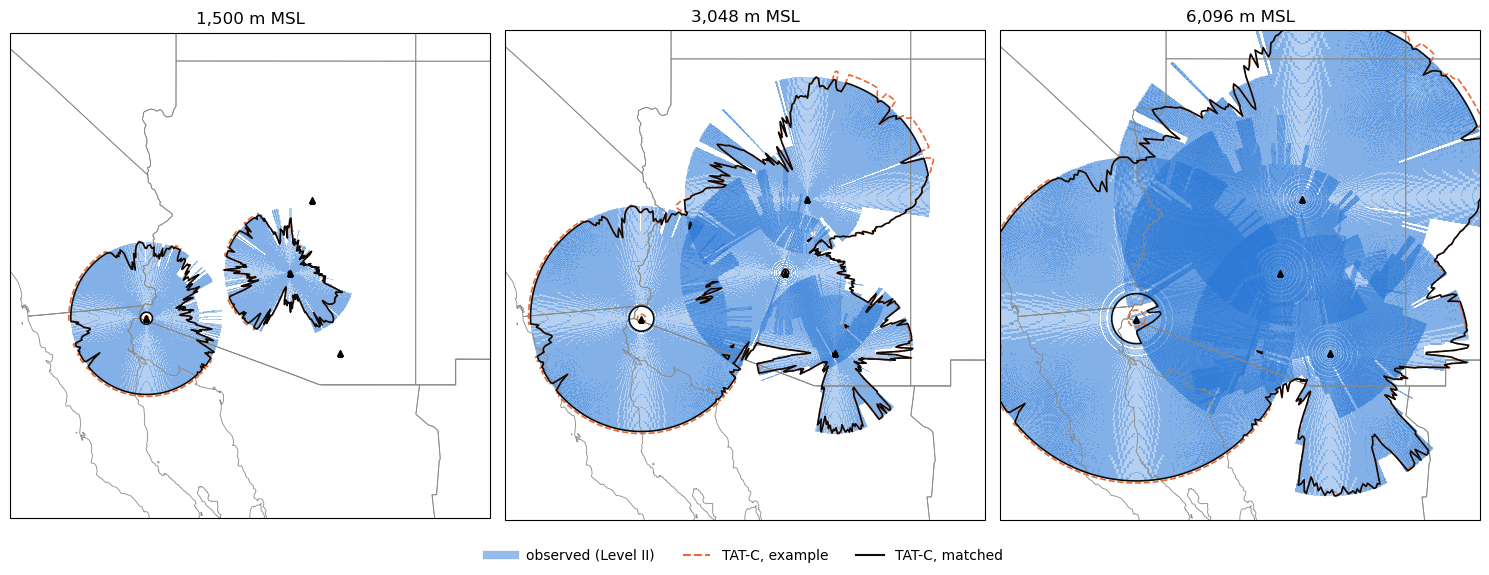

observed area (1000 km^2)  TAT-C area (1000 km^2)   IoU
1500 example                      93.63                   85.46  0.82
     matched                      93.63                   82.75  0.84
3048 example                     314.11                  304.83  0.88
     matched                     314.11                  297.32  0.90
6096 example                     618.59                  611.51  0.92
     matched                     618.59                  599.01  0.93

In [13]:
SNAPSHOT = datetime(2026, 9, 29, 12)
snapshot = {
    name: per_volume.loc[name].index[np.argmin(np.abs(volumes.set_index("key").loc[per_volume.loc[name].index, "time"] - SNAPSHOT))]
    for name in STATIONS
}
lon_grid, lat_grid = np.meshgrid(np.arange(-118, -106.99, 0.02), np.arange(28, 38.01, 0.02))
grid_area = np.cos(np.radians(lat_grid)) * (0.02 * 111.32) ** 2
range_edges = np.arange(461) * 1e3
corner_lonlat = {}
for name in STATIONS:
    az, rng = np.meshgrid(np.arange(361), range_edges, indexing="ij")
    lon, lat, _ = GEOD.fwd(np.full(az.shape, site.lon[name]), np.full(az.shape, site.lat[name]), az, rng)
    corner_lonlat[name] = (lon, lat)


def observed_on_grid(name, coverage):
    az, _, dist = GEOD.inv(np.full(lon_grid.shape, site.lon[name]), np.full(lon_grid.shape, site.lat[name]), lon_grid, lat_grid)
    i, j = (np.asarray(az) % 360).astype(int), (dist / 1e3).astype(int)
    inside = j < 460
    out = np.zeros(lon_grid.shape, dtype=bool)
    out[inside] = coverage[i[inside], j[inside]]
    return out


fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), subplot_kw={"projection": ccrs.PlateCarree()})
composite_rows = {}
for ax, height in zip(axes, HEIGHTS):
    observed_union = np.zeros(lon_grid.shape, dtype=bool)
    for name in STATIONS:
        coverage = observed_coverage(name, snapshot[name], height)
        observed_union |= observed_on_grid(name, coverage)
        ax.pcolormesh(*corner_lonlat[name], np.ma.masked_where(~coverage, coverage), cmap=ListedColormap([BLUE]), alpha=0.35, transform=ccrs.PlateCarree())
    composites = {
        "example": compute_radar_track(list(example_stations.values()), elevation=height),
        "matched": compute_radar_track([matched_station(name, snapshot[name]) for name in STATIONS], elevation=height),
    }
    for (config, composite), color, style in zip(composites.items(), [ORANGE, INK], ["--", "-"]):
        if not composite.empty:
            composite.boundary.plot(ax=ax, color=color, ls=style, lw=1.2, transform=ccrs.PlateCarree())
            geometry = composite.geometry.iloc[0]
        else:
            geometry = shapely.Polygon()
        predicted = shapely.contains_xy(geometry, lon_grid, lat_grid) if not geometry.is_empty else np.zeros(lon_grid.shape, dtype=bool)
        a_obs, a_pred = (observed_union * grid_area).sum(), (predicted * grid_area).sum()
        a_both = ((observed_union & predicted) * grid_area).sum()
        composite_rows[(height, config)] = {
            "observed area (1000 km^2)": a_obs / 1e3,
            "TAT-C area (1000 km^2)": a_pred / 1e3,
            "IoU": a_both / (a_obs + a_pred - a_both),
        }
    ax.plot(site.lon, site.lat, "k^", ms=5, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, edgecolor=GRAY, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, edgecolor=GRAY, linewidth=0.6)
    ax.set_extent([-117.5, -107.5, 29, 37.5], crs=ccrs.PlateCarree())
    ax.set_title(f"{height:,} m MSL")
axes[0].plot([], [], color=BLUE, alpha=0.5, lw=6, label="observed (Level II)")
axes[0].plot([], [], color=ORANGE, ls="--", label="TAT-C, example")
axes[0].plot([], [], color=INK, label="TAT-C, matched")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()
pd.DataFrame(composite_rows).T.round(2)

The composite maps show the same patterns. The matched network composite reaches an IoU of 0.84 at 1,500 m, 0.90 at 3,048 m, and 0.93 at 6,096 m, tracing the blocked sectors (wedges) of the observed coverage; the rings in the observed coverage are the gaps between upper tilts.

## Summary

| Test | Result |
| --- | --- |
| 1. Station siting (example vs. Level II) | Coordinates within 1 m; antenna elevations within 1.2 m (from the NCEI table) |
| 2. Scan strategy | Lowest tilts 0.44 to 0.53 deg, except -0.13 deg at `KFSX`; reflectivity to 460 km; highest tilt 6.4 to 19.5 deg in VCP 212 (38 to 100% of volumes ended early) and 6.4 deg in VCP 35 |
| 3. Terrain blockage (DEM mask vs. observed) | Lowest tilt agrees at 91 to 92% of azimuths; 93% over all low tilts; best criterion offset 0.15 deg |
| 4. Observable area (matched, 3,048 and 6,096 m) | IoU 0.77 to 0.92 per station (0.40 to 0.69 with `beam_width=0`); 0.84 to 0.93 for the network composite at all three heights; no coverage below the elevated antennas in either |

**Terrain masks.** DEM-derived terrain masks predict where NEXRAD beams are actually blocked, at the resolution of the data. Accurate antenna heights and adequate DEM sampling matter: terrain 50 to 100 km away sets the blocking angle along many azimuths around these stations, so a 100 km search radius with 1 deg azimuth sampling and geometrically spaced range samples (dense near the station) agrees up to 13 percentage points better than a 50 km radius with coarser, evenly spaced sampling, and an antenna height error of 100 m (as in an earlier version of the example for `KYUX`) shifts terrain angles by about 0.6 deg at 10 km. A beam-center blocking criterion is close to optimal, and TAT-C's coverage model, which hides only the part of the beam below the terrain angle, is consistent with the gradual loss of echo power observed.

**Beam width.** The largest systematic difference in observable area is the 0.95 deg beam width: real echoes come from the whole half-power beam, not just its center. `RadarStation.beam_width` (0.95 deg by default) extends the observed elevation angles by half the beam width beyond the lowest and highest beam centers, which reduces the share of the observed area outside the projected track from 29 to 58% to 7 to 18%. Gaps between widely spaced upper tilts are not represented.

**Scan strategy.** NEXRAD defaults in `RadarStation` describe a full precipitation-mode volume. The default 460 km range matches Level II reflectivity on the low tilts (the former 230 km default, a display-product range, reduced the example's IoU at 6,096 m to 0.53 to 0.70). The highest tilt (and hence the overhead cone of silence) depends on the VCP and on early volume termination, so `max_elevation_angle` should match the mode being modeled. Elevated sites such as `KFSX` scan below the horizon, now supported by a negative `min_elevation_angle`, which more than doubles `KFSX`'s outer range at 3,048 m.

**Targets below the antenna.** A radar cannot observe below its antenna unless its lowest beam points below local horizontal, and then only down to the lowest point of that beam. TAT-C reproduces this, so coverage maps at heights below an elevated station's antenna correctly show little or no coverage from that station. Target elevations are absolute and must be specified, so that a network composite describes coverage at a single height.

**Limitations.** Blockage is inferred from two precipitation events, so it depends on precipitation sampling and the vertical profile of reflectivity, and is treated (as in TAT-C) as affecting each blocked azimuth at all ranges. Observed coverage is reconstructed from each volume's actual sweeps using TAT-C's own standard-atmosphere beam model, so this validation does not test refraction, including anomalous propagation.